Data loaded successfully.
  CF results: 12 cases

Section 4: Governance Evaluation (G1–G4)


100%|████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00,  3.19it/s]


  [MiddleAged_Male_case1] Pre=4 CFs | Post=4 CFs


100%|████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00,  3.85it/s]


  [MiddleAged_Male_case2] Pre=4 CFs | Post=4 CFs


...

  [Older_Female_case1] Pre=4 CFs | Post=4 CFs


100%|████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00,  3.73it/s]


  [Older_Female_case2] Pre=4 CFs | Post=4 CFs


100%|████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00,  3.85it/s]


  [Older_Female_case3] Pre=4 CFs | Post=4 CFs
>>> Saved: ../results/tables/governance_results.csv

Section 5: Compliance Rate Summary

Compliance rates (%):
               G1_pass  G2_pass  G3_pass  G4_pass  All_pass
Condition                                                  
PostGuardrail   100.00   100.00   100.00    100.0    100.00
PreGuardrail     89.58    41.67    70.83     75.0     18.75

Post-guardrail compliance by group (%):
                   G1_pass  G2_pass  G3_pass  G4_pass  All_pass
Group                                                          
MiddleAged_Female    100.0    100.0    100.0    100.0     100.0
MiddleAged_Male      100.0    100.0    100.0    100.0     100.0
Older_Female         100.0    100.0    100.0    100.0     100.0
Older_Male           100.0    100.0    100.0    100.0     100.0

Section 6: Statistical Tests

[McNemar Test: Pre vs. Post Guardrail]
  G1 Physical Consistency            : Pre=89.4%  Post=100.0%  Δ=+10.6%  p=0.0625
  G2 Energy Safety Floor  

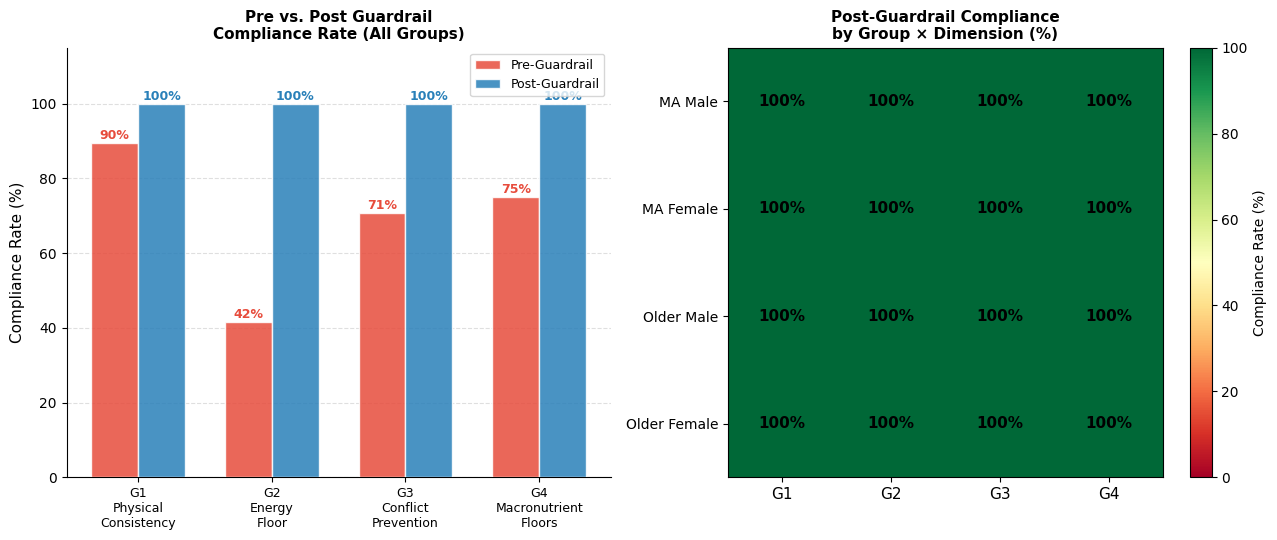

In [1]:
# 07_governance_check.ipynb
# =============================================================================
# Personalized Health Intervention Pathways for Comorbid Policyholders:
# Loss Ratio Management via LLM Guardrails and Counterfactual Explanations
# -----------------------------------------------------------------------------
# Notebook 07 — Guardrail Governance Check (G1–G4)
#
# Four governance dimensions evaluated across all 12 × 4 CF candidates:
#
#   G1. Physical Consistency
#       BMI, WaistCirc, Weight move in the same direction.
#       Metric: proportion of CFs with consistent anthropometric direction.
#
#   G2. Energy Safety Floor
#       Energy_kcal >= max(0.70 × baseline, 500 kcal) AND <= baseline.
#       Metric: proportion of CFs satisfying both floor and ceiling.
#
#   G3. Intervention Conflict Prevention
#       When Sodium_mg decreases, Carb_g and Sugar_g must not increase.
#       Metric: proportion of CFs free of sodium-carbohydrate conflict.
#
#   G4. Macronutrient Deficiency Prevention
#       Protein_g >= max(0.60c, 30), Potassium_mg >= max(0.50c, 500),
#       Carb_g >= max(0.20c, 30), Fiber_g >= max(0.30c, 5).
#       Metric: proportion of CFs satisfying all four macronutrient floors.
#
# Statistical tests:
#   - Compliance rate by group (descriptive)
#   - McNemar test: pre- vs. post-guardrail compliance (paired)
#   - Cochran's Q test: G1–G4 compliance rate homogeneity
#   - Fisher's exact test: group-level compliance differences
#
# Input  : ../results/tables/agent_config.pkl
#          ../results/tables/df_final.pkl
#          ../results/tables/model_{group}.pkl
#          ../results/tables/guardrail_ranges.json
#          ../results/tables/counterfactuals.json
# Output : ../results/tables/governance_results.csv
#          ../results/tables/governance_stats.csv
#          ../results/figures/figure_governance.{png|pdf|tiff}
# =============================================================================

# %%
# ## 0. Import Libraries

import json
import joblib
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import dice_ml

from scipy.stats import fisher_exact, chi2_contingency
from statsmodels.stats.contingency_tables import mcnemar

warnings.filterwarnings('ignore')

SAVE_FIG_KWARGS = dict(dpi=600, bbox_inches='tight', facecolor='white')

def save_fig(fig, name: str):
    for ext in ['png', 'pdf', 'tiff']:
        fig.savefig(f'../results/figures/{name}.{ext}',
                    format=ext, **SAVE_FIG_KWARGS)
    print(f"  Saved: {name} (PNG/PDF/TIFF 600 dpi)")

# %%
# ## 1. Load Data

agent_config = joblib.load('../results/tables/agent_config.pkl')
df_final     = joblib.load('../results/tables/df_final.pkl')

X_FEATURES      = agent_config['X_features']
VARY_FEATURES   = agent_config['vary_features']
TARGET_COL      = agent_config['target_col']
AGEGROUP_CONFIG = agent_config['agegroup_config']

models = {}
for group_name in AGEGROUP_CONFIG:
    try:
        models[group_name] = joblib.load(
            f'../results/tables/model_{group_name}.pkl'
        )
    except FileNotFoundError:
        models[group_name] = None

with open('../results/tables/guardrail_ranges.json', 'r', encoding='utf-8') as f:
    all_guardrails = json.load(f)

with open('../results/tables/counterfactuals.json', 'r', encoding='utf-8') as f:
    cf_data = json.load(f)

print("Data loaded successfully.")
print(f"  CF results: {len(cf_data['results'])} cases")

# %%
# ## 2. Governance Check Functions

def g1_physical_consistency(cf_row: dict, orig: dict,
                             tol: float = 1.0) -> bool:
    """
    G1: BMI, WaistCirc, Weight must move in the same direction.
    Pass = all non-trivial changes point in the same direction.
    """
    def sign(key):
        o = float(orig.get(key, 0))
        v = float(cf_row.get(key, o))
        pct = (v - o) / o * 100 if o != 0 else 0
        return np.sign(pct) if abs(pct) > tol else 0

    signs   = [sign(k) for k in ['BMI', 'WaistCirc', 'Weight']]
    nonzero = [s for s in signs if s != 0]
    if not nonzero:
        return True   # No change — trivially consistent
    return len(set(nonzero)) == 1


def g2_energy_safety(cf_row: dict, orig: dict) -> bool:
    """
    G2: Energy_kcal in [max(0.70c, 500), c].
    Pass = within safe floor and does not exceed baseline.
    """
    c     = float(orig.get('Energy_kcal', 0))
    v     = float(cf_row.get('Energy_kcal', c))
    floor = max(c * 0.70, 500.0)
    return floor <= v <= c * 1.01


def g3_conflict_prevention(cf_row: dict, orig: dict,
                            tol: float = 1.0) -> bool:
    """
    G3: If Sodium_mg decreases, Carb_g and Sugar_g must not increase.
    Pass = no compensatory carbohydrate/sugar increase when sodium cut.
    """
    c_na  = float(orig.get('Sodium_mg', 0))
    v_na  = float(cf_row.get('Sodium_mg', c_na))
    na_cut = (c_na - v_na) / c_na * 100 > tol if c_na > 0 else False

    if not na_cut:
        return True   # Sodium not reduced — no conflict risk

    c_carb  = float(orig.get('Carb_g',  0))
    v_carb  = float(cf_row.get('Carb_g',  c_carb))
    c_sugar = float(orig.get('Sugar_g', 0))
    v_sugar = float(cf_row.get('Sugar_g', c_sugar))

    carb_ok  = (v_carb  - c_carb)  / c_carb  * 100 <= tol if c_carb  > 0 else True
    sugar_ok = (v_sugar - c_sugar) / c_sugar * 100 <= tol if c_sugar > 0 else True
    return carb_ok and sugar_ok


def g4_macronutrient_floors(cf_row: dict, orig: dict) -> bool:
    """
    G4: Macronutrient deficiency prevention.
    Protein_g >= max(0.60c, 30)
    Potassium_mg >= max(0.50c, 500)
    Carb_g >= max(0.20c, 30)
    Fiber_g >= max(0.30c, 5)
    Pass = all four floors satisfied.
    """
    checks = [
        ('Protein_g',    0.60, 30.0),
        ('Potassium_mg', 0.50, 500.0),
        ('Carb_g',       0.20, 30.0),
        ('Fiber_g',      0.30, 5.0),
    ]
    for feat, ratio, abs_min in checks:
        c = float(orig.get(feat, 0))
        v = float(cf_row.get(feat, c))
        floor = max(c * ratio, abs_min)
        if v < floor * 0.99:   # 1% tolerance
            return False
    return True

# %%
# ## 3. Pure DiCE Generator (Pre-Guardrail Baseline)

def build_search_range(hard_ranges, df_ref, features):
    sr = {}
    for feat in features:
        hard_lo, hard_hi = hard_ranges.get(feat, [0, float('inf')])
        data_lo = float(df_ref[feat].quantile(0.05))
        data_hi = float(df_ref[feat].quantile(0.95))
        lo = max(min(hard_lo, data_lo), 0.0)
        hi = max(hard_hi, data_hi)
        sr[feat] = [round(lo, 4), round(hi, 4)]
    return sr

# %%
# ## 4. Evaluate Governance — Pre vs. Post Guardrail

print("\n" + "="*60)
print("Section 4: Governance Evaluation (G1–G4)")
print("="*60)

gov_records = []

for result in cf_data['results']:
    if result['status'] != 'success':
        continue

    case_key   = result['case_key']
    group_name = result['group']
    orig       = result['original']
    grd_cfs    = result['counterfactuals']
    gdata      = all_guardrails[case_key]
    hard_ranges = gdata['final_ranges']

    mdl = models.get(group_name)
    if mdl is None:
        continue

    cfg     = AGEGROUP_CONFIG[group_name]
    age_grp = 0.0 if cfg['age_min'] < 60 else 1.0
    df_ref  = df_final[
        (df_final['AgeGroup'] == age_grp) &
        (df_final['Sex']      == cfg['sex_code'])
    ].copy()

    query = pd.DataFrame([orig])[X_FEATURES]

    # Pure DiCE (pre-guardrail baseline)
    df_stable = df_final.copy().astype(float)
    d   = dice_ml.Data(
            dataframe=df_stable[X_FEATURES + [TARGET_COL]],
            continuous_features=X_FEATURES,
            outcome_name=TARGET_COL,
          )
    m   = dice_ml.Model(model=mdl, backend="sklearn")
    exp = dice_ml.Dice(d, m, method="genetic")

    try:
        cf_pure = exp.generate_counterfactuals(
            query, total_CFs=4, desired_class=0,
            features_to_vary=VARY_FEATURES,
            proximity_weight=0.2, sparsity_weight=0.1,
        )
        pure_cfs = cf_pure.cf_examples_list[0].final_cfs_df.to_dict(
            orient='records'
        ) if cf_pure else []
    except Exception:
        pure_cfs = []

    # Evaluate G1–G4 for each CF candidate
    for condition, cfs in [('PreGuardrail', pure_cfs),
                            ('PostGuardrail', grd_cfs)]:
        for cf_idx, cf_row in enumerate(cfs, start=1):
            g1 = g1_physical_consistency(cf_row, orig)
            g2 = g2_energy_safety(cf_row, orig)
            g3 = g3_conflict_prevention(cf_row, orig)
            g4 = g4_macronutrient_floors(cf_row, orig)
            gov_records.append({
                'CaseKey':   case_key,
                'Group':     group_name,
                'Condition': condition,
                'CF_idx':    cf_idx,
                'G1_pass':   int(g1),
                'G2_pass':   int(g2),
                'G3_pass':   int(g3),
                'G4_pass':   int(g4),
                'All_pass':  int(g1 and g2 and g3 and g4),
            })

    print(f"  [{case_key}] Pre={len(pure_cfs)} CFs | "
          f"Post={len(grd_cfs)} CFs")

gov_df = pd.DataFrame(gov_records)
gov_df.to_csv('../results/tables/governance_results.csv',
              index=False, encoding='utf-8-sig')
print(">>> Saved: ../results/tables/governance_results.csv")

# %%
# ## 5. Governance Compliance Summary

print("\n" + "="*60)
print("Section 5: Compliance Rate Summary")
print("="*60)

dims = ['G1_pass', 'G2_pass', 'G3_pass', 'G4_pass', 'All_pass']
dim_labels = {
    'G1_pass':  'G1 Physical Consistency',
    'G2_pass':  'G2 Energy Safety Floor',
    'G3_pass':  'G3 Conflict Prevention',
    'G4_pass':  'G4 Macronutrient Floors',
    'All_pass': 'All G1–G4',
}

# Pre vs. Post compliance rates
summary = gov_df.groupby('Condition')[dims].mean().round(4) * 100
print("\nCompliance rates (%):")
print(summary.to_string())

# By group (post-guardrail only)
group_summary = (
    gov_df[gov_df['Condition'] == 'PostGuardrail']
    .groupby('Group')[dims].mean().round(4) * 100
)
print("\nPost-guardrail compliance by group (%):")
print(group_summary.to_string())

# %%
# ## 6. Statistical Tests

print("\n" + "="*60)
print("Section 6: Statistical Tests")
print("="*60)

stats_records = []

# ── 6-1. McNemar Test: Pre vs. Post compliance for each dimension ─────────────
print("\n[McNemar Test: Pre vs. Post Guardrail]")

pre  = gov_df[gov_df['Condition'] == 'PreGuardrail'].set_index(
    ['CaseKey', 'CF_idx']
)
post = gov_df[gov_df['Condition'] == 'PostGuardrail'].set_index(
    ['CaseKey', 'CF_idx']
)
# Align indices
common_idx = pre.index.intersection(post.index)
pre  = pre.loc[common_idx]
post = post.loc[common_idx]

for dim in ['G1_pass', 'G2_pass', 'G3_pass', 'G4_pass']:
    pre_vals  = pre[dim].values
    post_vals = post[dim].values

    # McNemar contingency table
    # [both pass, pre pass post fail]
    # [pre fail post pass, both fail]
    n00 = int(((pre_vals == 0) & (post_vals == 0)).sum())
    n01 = int(((pre_vals == 0) & (post_vals == 1)).sum())
    n10 = int(((pre_vals == 1) & (post_vals == 0)).sum())
    n11 = int(((pre_vals == 1) & (post_vals == 1)).sum())

    table = np.array([[n11, n10], [n01, n00]])

    try:
        result = mcnemar(table, exact=True)
        p_val  = result.pvalue
        stat   = result.statistic
    except Exception:
        stat, p_val = np.nan, np.nan

    pre_rate  = pre_vals.mean()  * 100
    post_rate = post_vals.mean() * 100
    delta     = post_rate - pre_rate

    print(f"  {dim_labels[dim]:35s}: "
          f"Pre={pre_rate:.1f}%  Post={post_rate:.1f}%  "
          f"Δ={delta:+.1f}%  p={p_val:.4f}"
          f"{'  *' if p_val < 0.05 else ''}")

    stats_records.append({
        'Test':      'McNemar',
        'Dimension': dim,
        'Pre_pct':   round(pre_rate,  2),
        'Post_pct':  round(post_rate, 2),
        'Delta_pct': round(delta,     2),
        'Statistic': round(stat,      4) if not np.isnan(stat) else np.nan,
        'p_value':   round(p_val,     6) if not np.isnan(p_val) else np.nan,
        'Significant': 'Yes' if (not np.isnan(p_val) and p_val < 0.05) else 'No',
    })

# ── 6-2. Cochran's Q Test: G1–G4 compliance homogeneity (post-guardrail) ─────
print("\n[Cochran's Q Test: G1–G4 Compliance Homogeneity (Post-Guardrail)]")

post_only = gov_df[gov_df['Condition'] == 'PostGuardrail'].copy()
q_matrix  = post_only[['G1_pass', 'G2_pass', 'G3_pass', 'G4_pass']].values

k   = q_matrix.shape[1]   # number of dimensions
n   = q_matrix.shape[0]   # number of observations
L   = q_matrix.sum(axis=1)  # row sums
C   = q_matrix.sum(axis=0)  # column sums

Q = (k * (k - 1) * np.sum((C - n / k) ** 2)) / \
    (k * np.sum(L) - np.sum(L ** 2))

from scipy.stats import chi2 as chi2_dist
p_cochran = 1 - chi2_dist.cdf(Q, df=k - 1)

print(f"  Cochran's Q = {Q:.4f},  df = {k-1},  p = {p_cochran:.4f}"
      f"{'  *' if p_cochran < 0.05 else ''}")

stats_records.append({
    'Test':      "Cochran's Q",
    'Dimension': 'G1–G4 (all)',
    'Pre_pct':   np.nan,
    'Post_pct':  np.nan,
    'Delta_pct': np.nan,
    'Statistic': round(Q,         4),
    'p_value':   round(p_cochran, 6),
    'Significant': 'Yes' if p_cochran < 0.05 else 'No',
})

# ── 6-3. Fisher's Exact Test: Group-level G2 compliance (pre vs. post) ───────
print("\n[Fisher's Exact Test: G2 Energy Compliance by Group (Post-Guardrail)]")

for group in list(AGEGROUP_CONFIG.keys()):
    sub_pre  = gov_df[(gov_df['Group'] == group) &
                      (gov_df['Condition'] == 'PreGuardrail')]['G2_pass']
    sub_post = gov_df[(gov_df['Group'] == group) &
                      (gov_df['Condition'] == 'PostGuardrail')]['G2_pass']

    if len(sub_pre) == 0 or len(sub_post) == 0:
        continue

    n_pre_pass  = sub_pre.sum()
    n_pre_fail  = len(sub_pre)  - n_pre_pass
    n_post_pass = sub_post.sum()
    n_post_fail = len(sub_post) - n_post_pass

    table = np.array([[n_pre_pass,  n_pre_fail],
                      [n_post_pass, n_post_fail]])

    try:
        _, p_fe = fisher_exact(table)
    except Exception:
        p_fe = np.nan

    print(f"  {group:20s}: Pre={n_pre_pass}/{len(sub_pre)}  "
          f"Post={n_post_pass}/{len(sub_post)}  "
          f"p={p_fe:.4f}"
          f"{'  *' if (not np.isnan(p_fe) and p_fe < 0.05) else ''}")

    stats_records.append({
        'Test':      "Fisher's Exact (G2)",
        'Dimension': f'G2 — {group}',
        'Pre_pct':   round(n_pre_pass  / len(sub_pre)  * 100, 2),
        'Post_pct':  round(n_post_pass / len(sub_post) * 100, 2),
        'Delta_pct': round((n_post_pass / len(sub_post) -
                            n_pre_pass  / len(sub_pre)) * 100, 2),
        'Statistic': np.nan,
        'p_value':   round(p_fe, 6) if not np.isnan(p_fe) else np.nan,
        'Significant': 'Yes' if (not np.isnan(p_fe) and p_fe < 0.05) else 'No',
    })

stats_df = pd.DataFrame(stats_records)
stats_df.to_csv('../results/tables/governance_stats.csv',
                index=False, encoding='utf-8-sig')
print("\n>>> Saved: ../results/tables/governance_stats.csv")

# %%
# ## 7. Governance Figure

print("\n" + "="*60)
print("Section 7: Governance Figure")
print("="*60)

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

groups_order = ['MiddleAged_Male', 'MiddleAged_Female',
                'Older_Male',      'Older_Female']
group_labels = ['MA Male', 'MA Female', 'Older Male', 'Older Female']
dim_short    = ['G1', 'G2', 'G3', 'G4']
colors_dim   = ['#4C8CBF', '#27AE60', '#E67E22', '#8E44AD']

# Panel 1: Pre vs. Post compliance rates (all groups combined)
ax   = axes[0]
pre_rates  = [
    gov_df[(gov_df['Condition'] == 'PreGuardrail')][d].mean() * 100
    for d in dims[:4]
]
post_rates = [
    gov_df[(gov_df['Condition'] == 'PostGuardrail')][d].mean() * 100
    for d in dims[:4]
]

x = np.arange(4)
w = 0.35
bars_pre  = ax.bar(x - w/2, pre_rates,  w, label='Pre-Guardrail',
                   color='#E74C3C', edgecolor='white', alpha=0.85, zorder=3)
bars_post = ax.bar(x + w/2, post_rates, w, label='Post-Guardrail',
                   color='#2980B9', edgecolor='white', alpha=0.85, zorder=3)

for bar, v in zip(bars_pre,  pre_rates):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'{v:.0f}%', ha='center', fontsize=9, color='#E74C3C',
            fontweight='bold')
for bar, v in zip(bars_post, post_rates):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'{v:.0f}%', ha='center', fontsize=9, color='#2980B9',
            fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(['G1\nPhysical\nConsistency',
                    'G2\nEnergy\nFloor',
                    'G3\nConflict\nPrevention',
                    'G4\nMacronutrient\nFloors'],
                   fontsize=9)
ax.set_ylabel('Compliance Rate (%)', fontsize=11)
ax.set_ylim(0, 115)
ax.legend(fontsize=9)
ax.yaxis.grid(True, linestyle='--', alpha=0.4, zorder=0)
ax.set_axisbelow(True)
ax.spines[['top', 'right']].set_visible(False)
ax.set_title('Pre vs. Post Guardrail\nCompliance Rate (All Groups)',
             fontsize=11, fontweight='bold')

# Panel 2: Post-guardrail compliance heatmap by group × dimension
ax = axes[1]
heat_data = np.array([
    [
        gov_df[(gov_df['Group'] == g) &
               (gov_df['Condition'] == 'PostGuardrail')][d].mean() * 100
        for d in dims[:4]
    ]
    for g in groups_order
])

import matplotlib.colors as mcolors
cmap = plt.cm.RdYlGn
norm = mcolors.Normalize(vmin=0, vmax=100)
im   = ax.imshow(heat_data, cmap=cmap, norm=norm, aspect='auto')

for i in range(len(groups_order)):
    for j in range(4):
        val = heat_data[i, j]
        ax.text(j, i, f'{val:.0f}%', ha='center', va='center',
                fontsize=11, fontweight='bold',
                color='white' if val < 50 else 'black')

ax.set_xticks(range(4))
ax.set_xticklabels(['G1', 'G2', 'G3', 'G4'], fontsize=11)
ax.set_yticks(range(len(groups_order)))
ax.set_yticklabels(group_labels, fontsize=10)
ax.set_title('Post-Guardrail Compliance\nby Group × Dimension (%)',
             fontsize=11, fontweight='bold')
plt.colorbar(im, ax=ax, label='Compliance Rate (%)')

fig.tight_layout()
save_fig(fig, 'figure_governance')
plt.show()